In [1]:
import pandas as pd
import torch
import tqdm
from IPython.display import Audio

In [2]:
df = pd.read_csv('dataset.csv', sep=';')
df

,filename,duration,samplerate,tags,target
0,good/00f3da84-570e-40f5-9949-31cd811ff6ca.wav,12.415625,16000,чстрлшщ,1
1,good/01062fc6-fbb8-4544-a0f5-2830899a91d0.wav,6.480000,16000,чстр,1
2,good/01611791-7a64-42c6-82f4-1f8d46603999.wav,11.940000,16000,лш,1
3,good/0165e884-ccbe-4a43-b2e8-fa64952dc825.wav,3.436187,16000,рлш,1
4,good/018e28b3-b8de-4023-b2d8-39c6455c6f33.wav,5.280000,16000,стрлш,1
...,...,...,...,...,...
2777,bad/ff366031-a519-49e4-a34e-156be75f128d.wav,18.680000,16000,стлш,0
2778,bad/ff7b8da9-595b-4ee6-bd15-7016f543ec34.wav,6.501188,16000,стрлш,0
2779,bad/ffb3b065-80b4-44b2-bd89-f67e138e41d2.wav,6.760000,16000,рл,0
2780,bad/ffcc0732-1dd2-41d9-bf5d-0bbdb8f48dd0.wav,8.540000,16000,стрл,0


In [3]:
df['samplerate'].value_counts()

samplerate
16000    2782
Name: count, dtype: int64

<Axes: >

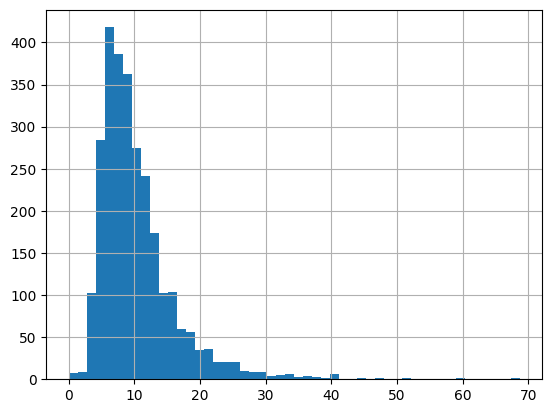

In [4]:
df['duration'].hist(bins=50)

In [5]:
df['tags'].value_counts()

tags
трл        296
стрл       216
стрш       156
стр        131
стлш       130
срл        128
стрлш      126
стрлц       99
тлщ         99
трлш        97
рлш         97
чтр         68
трш         68
рл          65
трлц        65
чстлш       65
тл          62
чстрл       62
трщ         36
сл          35
чстш        35
чстлщ       34
чтл         33
чтрлц       33
стлщ        33
р           32
чстр        32
стлц        32
чслц        31
ст          31
лш          31
слц         30
рш          30
л           30
чрл         30
чстрлш      30
чсрлц       30
чстрлшщ     30
стрлцш      29
чстрш       29
тр          28
чтшщ        28
Name: count, dtype: int64

In [6]:
df['target'].value_counts()

target
1    1875
0     907
Name: count, dtype: int64

In [7]:
df.nlargest(n=10, columns='duration')

,filename,duration,samplerate,tags,target
1933,bad/0dd288ea-7d35-40b1-82e7-99e129ba9c2f.wav,68.660000,16000,чстрлш,0
2369,bad/7db22961-8c0a-4adc-b590-969e94f84a7e.wav,59.233688,16000,чстрлш,0
2497,bad/9dc0de35-8091-4094-ab93-773ce55feec5.wav,51.222813,16000,чстрлш,0
2221,bad/53c838ab-6693-40ce-886c-a4b37094db4a.wav,47.120000,16000,чстрлш,0
2532,bad/a8e569bb-b76c-4e24-bb80-5a734808b5f7.wav,46.920000,16000,трлш,0
1320,good/ba3d2624-07bf-4c76-af14-e42d5ad7d69a.wav,44.100000,16000,чстрл,1
1875,bad/00324acf-33cf-467f-8355-9b0d880a479f.wav,40.880000,16000,чстрл,0
2157,bad/45a62e68-60de-4d71-b854-0f8585be9255.wav,40.600000,16000,чстрлшщ,0
1954,bad/1423cc6a-dd47-4be0-a281-f57cd186264c.wav,40.380000,16000,стрлш,0
2585,bad/b86c3f2a-a470-44d0-a742-28f3a372d441.wav,40.160000,16000,трл,0


In [8]:
df.nsmallest(n=10, columns='duration')

,filename,duration,samplerate,tags,target
2143,bad/429980b8-5979-41c8-847f-21739fcdfb5e.wav,0.000000,16000,слц,0
2421,bad/8803cf6d-1c43-4453-90b4-b8047e599323.wav,0.000000,16000,тлщ,0
2450,bad/904117a9-7971-4722-82cb-a2b9df69cd44.wav,0.529563,16000,чсрлц,0
2766,bad/fc014530-281f-48a6-a8ed-90663a484f1a.wav,0.754250,16000,трш,0
2466,bad/933eed1a-8629-47bc-8304-7ec5ca65e6a2.wav,0.894625,16000,стрл,0
2026,bad/27f03007-3b1e-4f98-9335-2cb45eb4f0d0.wav,0.927687,16000,стлц,0
2435,bad/8c6aad07-02a0-43e4-9762-2242ab7ba305.wav,0.987938,16000,трщ,0
2254,bad/5d0a9ee2-f0c7-4f3c-9b13-b661331b2695.wav,1.249313,16000,рлш,0
2205,bad/4fd8801a-d7cb-41f6-9080-5a55b4097121.wav,1.395188,16000,трл,0
1058,good/980e1f03-da88-4bf7-9d6a-3e1be58b8a64.wav,2.280000,16000,тлщ,1


Видим, что есть два пустых файла, помимо этого, несколько файлов длительностью менее секунды, не содержат речи. Удалим из датасета записи о них. Для проверки, есть ли в wav файле речь используем модель VGGish, она работает быстро и выдает исключение, если речь отсутствует.

In [ ]:
model = torch.hub.load('harritaylor/torchvggish', 'vggish')
model.eval()

bad_files = []
for row in tqdm.tqdm(df.itertuples(index=True), total=df.shape[0]):
    try:
        model.forward(row.filename)
    except:
        bad_files.append(row.filename)

Using cache found in /home/dk/.cache/torch/hub/harritaylor_torchvggish_master
2782it [04:36, 10.07it/s]


In [10]:
for bad_file in bad_files:
    print(bad_file)
    display(Audio(bad_file))

bad/27f03007-3b1e-4f98-9335-2cb45eb4f0d0.wav


bad/429980b8-5979-41c8-847f-21739fcdfb5e.wav


bad/8803cf6d-1c43-4453-90b4-b8047e599323.wav


bad/904117a9-7971-4722-82cb-a2b9df69cd44.wav


bad/933eed1a-8629-47bc-8304-7ec5ca65e6a2.wav


bad/fc014530-281f-48a6-a8ed-90663a484f1a.wav


In [11]:
df = df[~df['filename'].isin(bad_files)]
df

,filename,duration,samplerate,tags,target
0,good/00f3da84-570e-40f5-9949-31cd811ff6ca.wav,12.415625,16000,чстрлшщ,1
1,good/01062fc6-fbb8-4544-a0f5-2830899a91d0.wav,6.480000,16000,чстр,1
2,good/01611791-7a64-42c6-82f4-1f8d46603999.wav,11.940000,16000,лш,1
3,good/0165e884-ccbe-4a43-b2e8-fa64952dc825.wav,3.436187,16000,рлш,1
4,good/018e28b3-b8de-4023-b2d8-39c6455c6f33.wav,5.280000,16000,стрлш,1
...,...,...,...,...,...
2777,bad/ff366031-a519-49e4-a34e-156be75f128d.wav,18.680000,16000,стлш,0
2778,bad/ff7b8da9-595b-4ee6-bd15-7016f543ec34.wav,6.501188,16000,стрлш,0
2779,bad/ffb3b065-80b4-44b2-bd89-f67e138e41d2.wav,6.760000,16000,рл,0
2780,bad/ffcc0732-1dd2-41d9-bf5d-0bbdb8f48dd0.wav,8.540000,16000,стрл,0


In [12]:
df.to_csv('dataset.csv', sep=';', index=False)